## Adding external forces to the simulation

This is theory notebook 4/4. See the previous three for the simulation code we add to here.

In this notebook we develop external forces acting on objects during the simulation. This may be useful for scenarios where one simulates some part of a gas that is within a larger gravitational field of e.g. a star, or, considering other forces, a system that is placed within a constant magnetic field. Or maybe you want to put particles in a box that is also oscillating by itself; there are plenty of fun scenarios to come up with.

Below, one example of an external force with a number of parameters is used, but this can be replaced for whatever one would like, with less or more parameters. It will be added as one of the initial conditions that need to be set for the simulation.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

To start, we add a parameter `use_external_force` which can be set to `False` in case you don't want to add this force, which is a bit easier than having the function return zero. In case you do want to add the force, it has to be defined as `external_force()`.

One note is that if you want to make your force time-dependent, and also have its initial value set at some initial time that is not zero, this has to be accounted for in this function as well, as the simulation always starts at $t=0$. It can be done by for instance writing the force as $F(t) = f_0 + f(t)$ where $f(0)=0$, or by adding the initial time as a parameter, as below. Something similar could also be done with the positions, in case you don't want to center the force on the origin.

In [13]:
use_external_force = True

def external_force(mass, time, initial_time=0, force_constant=1):
    """
    An example of an external force; this one oscillates sinusoidally with time 
    on the y-axis and is proportional to the mass of the object.
    Parameters:
    - mass (float): The mass of the object
    - time (float): The simulation time
    - initial_time (float): A parameter to shift the time for the force calculation
    - force_constant (float): A constant to scale the force
    """
    used_time = time + initial_time
    direction_vector = np.array([0, 1, 0])  # force in the y-direction
    return force_constant * mass * np.sin(2 * np.pi * used_time) * direction_vector

Let's then copy the main simulation loop before, where we now also add the external force on top of the force between objects. To show the influence of this force clearly here, we will use small masses but set the `force_constant` parameter to be large, so that the external force dominates.

In [14]:
# Constants of the simulation
G = 1
dt = 1e-3  # timestep
N_steps = 5000
N_objects = 3
e = 1.0  # coefficient of restitution
box_length = None
periodic = False
e_wall = None
times = np.arange(N_steps) * dt
external_force_constant = 100

# Make an array with the mass and radius of each object
masses = np.array([0.01, 0.01, 0.01])
radii = np.array([0.01, 0.01, 0.01])

# Make an array 'positions' to mark the positions of the objects
# Here positions[i] are the positions of all objects at timestep i,
# positions[i][j] is the position of object j at timestep i,
# positions[i][j][k] is the k-coordinate of object j at timestep i.
positions = np.zeros(shape=[N_steps, N_objects, 3])  # 3 for x, y, z coordinates

# Choose initial positions
positions[0][0] = np.array([1,0,0])
positions[0][1] = np.array([-1,0,0])
positions[0][2] = np.array([0,0,0])

# Make an array 'velocities' to mark the velocities of the objects
# with the same structure as positions
velocities = np.zeros(shape=[N_steps, N_objects, 3])

# Choose initial velocities
velocities[0][0] = np.array([1,0,0])
velocities[0][1] = np.array([-1,0,0])
velocities[0][2] = np.array([0,0,0])

In [ ]:
def gravity_force(m_i, m_j, r_i, r_j):
    """
    Calculate the gravitational force exerted on object i by object j.
    Parameters:
        - m_i (float): Mass of object i
        - m_j (float): Mass of object j
        - r_i (np.array): Position vector of object i
        - r_j (np.array): Position vector of object j
    """
    r_ij = r_i - r_j
    distance = np.linalg.norm(r_ij)
    unit_r_ij = r_ij / distance
    return -G * m_i * m_j / distance**2 * unit_r_ij

def next_velocity(current_velocity, next_acceleration, current_acceleration):
    """
    Find the velocity at the next timestep using the Verlet integration method.
    Parameters:
        - current_velocity (np.array): Velocity at the current timestep
        - next_acceleration (np.array): Acceleration at the next timestep
        - current_acceleration (np.array): Acceleration at the current timestep
    """
    return current_velocity + 0.5 * dt * (next_acceleration + current_acceleration)

def next_position(current_position, current_velocity, current_acceleration):
    """
    Find the position at the next timestep using the velocity Verlet integration method.
    Parameters:
        - current_position (np.array): Position at the current timestep
        - current_velocity (np.array): Velocity at the current timestep
        - current_acceleration (np.array): Acceleration at the current timestep
    """
    return current_position + current_velocity * dt + 0.5 * current_acceleration * dt**2

def galilean_transform(target_velocity, frame_velocity):
    """
    Perform a Galilean transformation.
    Parameters:
        - target_velocity (np.array): Velocity of the object that is to be transformed
        - frame_velocity (np.array): Velocity of the frame you want to transform to
    """
    return target_velocity - frame_velocity

def get_rotation_angles(position_i, position_j):
    """
    Calculate the rotation angles around the axes to align with 
    the line between the centres of the objects i and j.
    Parameters:
        - position_i (np.array): Position vector of object i
        - position_j (np.array): Position vector of object j
    Returns:
        - alpha (float): Angle around the x axis
        - beta (float): Angle around the y axis
        - gamma (float): Angle around the z axis
    """
    difference = position_i - position_j  # (delta_x, delta_y, delta_z)
    # Using arctan2 ensures the right quadrant sign
    alpha = np.arctan2(difference[2], difference[1])
    beta = np.arctan2(difference[0], difference[2])
    gamma = np.arctan2(difference[1], difference[0])
    return alpha, beta, gamma

def rotation(alpha, beta, gamma, target_vector):
    """
    Perform a rotation around the x, y and z axis.
    Parameters:
        - alpha (float): Angle around the x axis
        - beta (float): Angle around the y axis
        - gamma (float): Angle around the z axis
        - target_vector (np.array): Vector you want to rotate
    """
    rotation_matrix_x = np.array([
        [1, 0, 0],
        [0, np.cos(alpha), -np.sin(alpha)],
        [0, np.sin(alpha), np.cos(alpha)]
    ])
    rotation_matrix_y = np.array([
        [np.cos(beta), 0, np.sin(beta)],
        [0, 1, 0],
        [-np.sin(beta), 0, np.cos(beta)]
    ])
    rotation_matrix_z = np.array([
        [np.cos(gamma), -np.sin(gamma), 0],
        [np.sin(gamma), np.cos(gamma), 0],
        [0, 0, 1]
    ])
    combined_rotation = rotation_matrix_x @ rotation_matrix_y @ rotation_matrix_z  # Note xyz
    return combined_rotation @ target_vector

def inverse_rotation(alpha, beta, gamma, target_vector):
    """
    Perform an inverse rotation around the x, y and z axis,
    compared to the function above. Note no minus sign on the
    angles is needed relative to above!
    Parameters:
        - alpha (float): Angle around the x axis
        - beta (float): Angle around the y axis
        - gamma (float): Angle around the z axis
        - target_vector (np.array): Vector you want to rotate
    """
    rotation_matrix_x = np.array([
        [1, 0, 0],
        [0, np.cos(alpha), -np.sin(-alpha)],
        [0, np.sin(-alpha), np.cos(alpha)]
    ])
    rotation_matrix_y = np.array([
        [np.cos(beta), 0, np.sin(-beta)],
        [0, 1, 0],
        [-np.sin(-beta), 0, np.cos(beta)]
    ])
    rotation_matrix_z = np.array([
        [np.cos(gamma), -np.sin(-gamma), 0],
        [np.sin(-gamma), np.cos(gamma), 0],
        [0, 0, 1]
    ])
    combined_rotation = rotation_matrix_z @ rotation_matrix_y @ rotation_matrix_x  # Note zyx
    return combined_rotation @ target_vector

def velocity_transfer_collision(m_i, m_j, velocity_before_i):
    """
    Calculate the velocity of object i and j after an (in)elastic
    collision, where i moves and j is stationary.
    Parameters:
        - m_i (float): Mass of object i
        - m_j (float): Mass of object j
        - velocity_before_i (np.array): Velocity of object i before the collision
    Returns:
        - velocity_after_i (np.array): Velocity of object i after the collision
        - velocity_after_j (np.array): Velocity of object j after the collision
    """
    velocity_after_i = (m_i - e * m_j) / (m_i + m_j) * velocity_before_i
    velocity_after_j = (1 + e) * m_i / (m_i + m_j) * velocity_before_i
    return velocity_after_i, velocity_after_j

def objects_move_towards_each_other(position_i, position_j, velocity_i, velocity_j):
    """
    Determine if objects i and j are moving towards each other, so that a collision 
    can happen. This is the case if for any of the components of the position and 
    velocity vectors, the position component of i is smaller and the velocity 
    component of i is larger, or vice versa.
    Parameters:
        - position_i (np.array): Position vector of object i
        - position_j (np.array): Position vector of object j
        - velocity_i (np.array): Velocity vector of object i
        - velocity_j (np.array): Velocity vector of object j
    Returns:
        - bool: True if objects move towards each other
    """
    position_mask = position_i > position_j
    velocity_mask = velocity_i > velocity_j
    # We need position_i to be smaller and velocity_i larger or vice versa,
    # meaning these masks do not have the same value
    collisions = position_mask != velocity_mask
    # If any of these is True, there will be a collision
    return np.any(collisions)

def velocity_transfer_collision_wall(velocity_before_i):
    """
    Calculate the velocity of object i after an (in)elastic
    collision with the wall.
    Parameters:
        - velocity_before_i (np.array): Velocity of object i before the collision
    Returns:
        - velocity_after_i (np.array): Velocity of object i after the collision
    """
    velocity_after_i = -e_wall * velocity_before_i
    return velocity_after_i

def wall_collision_check_and_transfer(position_i, velocity_i):
    """
    Check if the object is colliding for each axis/component,
    and apply the velocity transfer if so.
    Parameters:
        - position_i (np.array): Position vector of object i
        - velocity_i (np.array): Velocity vector of object i
    Returns:
        - velocity_after_i (np.array): Velocity vector of object i after wall collision
    """
    walls = 0.5*np.array([box_length]*3)
    # Find where the object is outside the box
    where_cross = np.logical_or(position_i > walls, position_i < -walls)

    # Determine if a collision can happen, if the object moves towards the wall
    collisions = (position_i > 0) == (velocity_i > 0)

    # Apply velocity transfer where both conditions are met per component
    velocity_after_i = np.where(
        np.logical_and(where_cross, collisions),
        velocity_transfer_collision_wall(velocity_i),
        velocity_i
    )
    return velocity_after_i

def closest_copy_coordinates(position_i, positions):
    """
    Find the coordinates of the closest copy of each object relative to
    the object i according to the minimal image convention.
    Parameters:
        - position_i (np.array): Position vector of object i
        - positions (np.array): Array of position vectors of all objects
    Returns:
        - copy_positions (np.array): Array of position vectors of the closest copies of all objects
    """
    copy_positions = position_i -  (position_i - positions + 0.5*box_length) % box_length + 0.5*box_length
    return copy_positions

def apply_periodic_crossing(position_i):
    """
    Check if an object has crossed the periodic boundary, 
    and apply the correction in position if so.
    Parameters:
        - position_i (np.array): Position vector of object i
    Returns:
        - crossed_positions (np.array): Position vector of object i after applying periodic crossing correction
    """
    crossed_positions = np.copy(position_i)
    where_cross_positive = position_i > 0.5*box_length
    where_cross_negative = position_i < -0.5*box_length
    crossed_positions[where_cross_positive] -= box_length
    crossed_positions[where_cross_negative] += box_length
    return crossed_positions

# Also need to keep the previous acceleration for velocity
# Note we don't save these for all timesteps, only the previous one
previous_accelerations = np.zeros(shape=[N_objects, 3])

# Then also determine acceleration for step 0
for j in range(N_objects):
    force = np.zeros(3)  # to add up all forces on object j

    if periodic:  # get closest copy positions for object j
        copy_positions = closest_copy_coordinates(positions[0][j], positions[0])

    # Calculate the force between objects
    for k in range(N_objects):
        # Consider all other objects k, so without k==j
        if k != j:
            # Check for periodic box
            if not periodic:
                force += gravity_force(masses[j], masses[k], positions[0][j], positions[0][k])
            else:  # Apply minimal image convention
                force += gravity_force(masses[j], masses[k], positions[0][j], copy_positions[k])
    
    # Calculate the external force
    if use_external_force:
        force += external_force(masses[j], 0, force_constant=external_force_constant)
    
    previous_accelerations[j] = force / masses[j]  # update these to contain step 0 accelerations

# Main simulation loop
for i in range(1, N_steps):  # 0 set by initial conditions
    for j in range(N_objects):
        # Update positions, with the already calculated previous acceleration
        positions[i][j] = next_position(positions[i-1][j], velocities[i-1][j], previous_accelerations[j])
    
    # Once all positions are updated, calculate new accelerations and update velocities
    for j in range(N_objects):
        force = np.zeros(3)  # to add up all forces on object j

        if periodic:  # get closest copy positions for object j
            copy_positions = closest_copy_coordinates(positions[i][j], positions[i])

        # Calculate the force between objects
        for k in range(N_objects):
            # Consider all other objects k, so without k==j
            if k != j:
                # Check for periodic box
                if not periodic:
                    force += gravity_force(masses[j], masses[k], positions[i][j], positions[i][k])
                else:  # Apply minimal image convention
                    force += gravity_force(masses[j], masses[k], positions[i][j], copy_positions[k])
        
        # Calculate the external force
        if use_external_force:
            force += external_force(masses[j], times[i], force_constant=external_force_constant)
        
        acceleration = force / masses[j]

        # So update velocities
        velocities[i][j] = next_velocity(velocities[i-1][j], acceleration, previous_accelerations[j])
        # And update the previous acceleration for the next loop
        previous_accelerations[j] = acceleration
    
    # Collisions
    for j in range(N_objects):
        position_j = positions[i][j]
        velocity_j = velocities[i][j]
        # Now only check for collisions between object pairs
        for k in range(j+1, N_objects):
            position_k = positions[i][k]
            velocity_k = velocities[i][k]
            # Check collision condition
            difference = position_j - position_k
            distance = np.linalg.norm(difference)
            if distance <= (radii[j] + radii[k]) and objects_move_towards_each_other(position_j, position_k, velocity_j, velocity_k):
                # 1 Galilean transform, with velocity_k as the frame velocity
                transformed_velocity = galilean_transform(velocity_j, velocity_k)

                # 2 Rotation
                alpha, beta, gamma = get_rotation_angles(position_j, position_k)
                rotated_transformed_velocity = rotation(alpha, beta, gamma, transformed_velocity)

                # 3 Velocity transfer
                velocity_after_j, velocity_after_k = velocity_transfer_collision(masses[j], masses[k], rotated_transformed_velocity)

                # 4 Inverse rotation
                velocity_after_j = inverse_rotation(alpha, beta, gamma, velocity_after_j)
                velocity_after_k = inverse_rotation(alpha, beta, gamma, velocity_after_k)

                # 5 Inverse Galilean transform
                velocity_after_j = galilean_transform(velocity_after_j, -velocity_k)
                velocity_after_k = galilean_transform(velocity_after_k, -velocity_k)

                # And finally assign
                velocities[i][j] = velocity_after_j
                velocities[i][k] = velocity_after_k
    
    # Boundary conditions
    if box_length is None:
        continue  # no boundary conditions, so skip to next timestep

    for j in range(N_objects):
        # Check if the object is outside the box
        if np.any(np.abs(positions[i][j]) > 0.5*box_length):
            # Check finite or periodic box
            if not periodic:
                velocities[i][j] = wall_collision_check_and_transfer(positions[i][j], velocities[i][j])
            else:
                positions[i][j] = apply_periodic_crossing(positions[i][j])

# Calculate energies
kinetic_per_particle = 0.5 * masses * np.sum(velocities**2, axis=2)
kinetic_total = np.sum(kinetic_per_particle, axis=1)

potential_total = np.zeros(shape=[N_steps])
for j in range(N_objects-1):  # don't need to consider the last object, is cancelled in next loop
    r_j = positions[:,j,:]
    for k in range(j+1, N_objects):  # start from the object after j
        if not periodic:
            r_k = positions[:,k,:]
            distance = np.linalg.norm(r_j - r_k, axis=1)  # distance between j and k at all timesteps
        else:  # Apply minimal image convention
            copy_r_k = closest_copy_coordinates(r_j, positions[:,k,:])
            distance = np.linalg.norm(r_j - copy_r_k, axis=1)
        potential_jk = -G * masses[j] * masses[k] / distance
        potential_total += potential_jk

energy = kinetic_total + potential_total

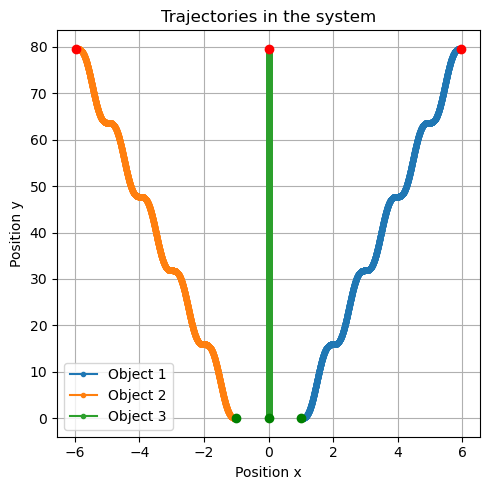

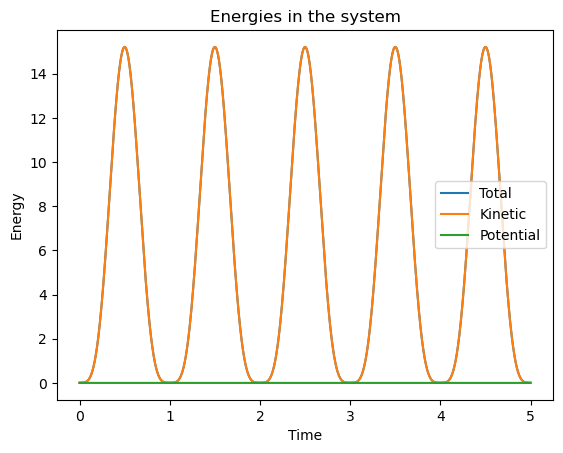

In [16]:
# Plot of trajectories in xy-plane
plt.figure(figsize=(5,5))
for i in range(N_objects):
    obj_i_positions = positions[:,i,:]
    plt.plot(obj_i_positions[:,0], obj_i_positions[:,1], marker='.', label=f'Object {i+1}')
    # Object starts at green dot, ends at red dot
    plt.plot(obj_i_positions[0,0], obj_i_positions[0,1], marker='.', color='green', markersize=12)
    plt.plot(obj_i_positions[-1,0], obj_i_positions[-1,1], marker='.', color='red', markersize=12)

plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Trajectories in the system')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Plot the different energies over time
plt.figure()
plt.plot(times, energy, label="Total")
plt.plot(times, kinetic_total, label="Kinetic")
plt.plot(times, potential_total, label="Potential")
plt.title("Energies in the system")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

That looks as expected: the object on the right has a constant, unchanged speed in the positive $x$-direction, while it us pushed in the positive $y$-direction by the external force. As the force increases, it accelerates, until the force decreases again and reverses direction, so that the object is slowed down again until only the original $x$ speed is left, as seen in the horizontal bits of the trajectory. Then this repeats a couple times. The same but mirrored thing happens for the object on the left, while the object in the middle is just being pushed and pulled and pushed and pulled upwards, but that is not directly visible in this plot, as it just results in a straight line.

We also see that the total energy is no longer conserved, which is of course expected when we add an external force that keeps changing the energy in the system by doing work on the objects. If we do take the work into account, the energy should stay constant again, in the sense that $T + U - W = \mathrm{const.}$ where $W$ is the work. This is defined as $W(t) = \int_0^t \vec{F}(t') \cdot d\vec{x}(t')$, so we can calculate it numerically using the force and displacement in each timestep. Here we also need to take into account that the displacement occurs "in between" timesteps, so we average the force between those timesteps as well to get a better result.

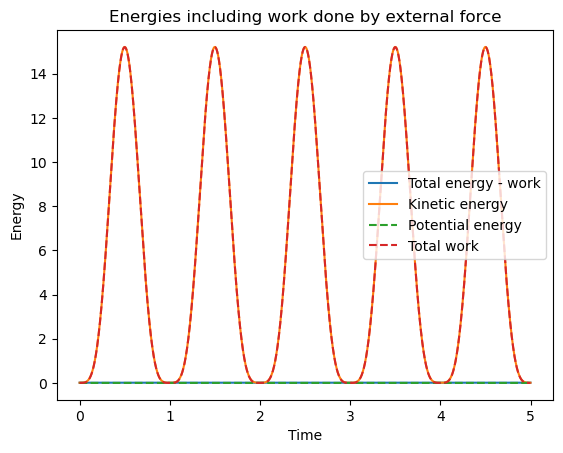

In [17]:
work_per_timestep = [0]  # start at 0 work done
for i in range(1, N_steps):
    work_i = 0
    for j in range(N_objects):
        displacement = positions[i][j] - positions[i-1][j]
        force_i = external_force(masses[j], times[i], force_constant=external_force_constant)
        force_i_minus_1 = external_force(masses[j], times[i-1], force_constant=external_force_constant)
        # Trapezoidal rule: average the force at the start and end of the timestep
        avg_force = 0.5 * (force_i + force_i_minus_1)
        work_i += np.dot(avg_force, displacement)
    work_per_timestep.append(work_i)
work_per_timestep = np.array(work_per_timestep)
# Take the cumulative sum since we look at the total amount of energy added to the system at each timestep, 
# which thus includes all that is added at earlier times
total_work = np.cumsum(work_per_timestep)

plt.figure()
plt.plot(times, energy - total_work, label="Total energy - work")
plt.plot(times, kinetic_total, label="Kinetic energy")
plt.plot(times, potential_total, label="Potential energy", linestyle='dashed')
plt.plot(times, total_work, label='Total work', linestyle='dashed')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.legend()
plt.title('Energies including work done by external force')
plt.show()

As you can see it all lines up very nicely, such that all kinetic energy is the result of the work done by the external force (which we note can also take energy out of the system again so that the kinetic energy decreases; here the "work done per timestep" is negative) and the total energy minus the work remains constant.

For fun, and for a second validation, we can also calculate the work theoretically. Since we can see the potential energy is negligible (because the gravitational force is so small because we set the masses to be small), the acceleration of the objects is entirely determined by the external force, so that $\vec{a}(t) = \vec{F}(t)/m$ and $\vec{v}(t) = \frac{1}{m} \int \vec{F}(t) dt$.

With out force expression as defined in the function at the top of the script, $\vec{F}(t) = A m \sin(2\pi t) \: \hat{y}$, with $A$ as the force constant, we find
\begin{equation}
    \nonumber
    \vec{v}(t) = v_0 \hat{x} + \frac{A}{2\pi} \left( 1 - \cos(2\pi t) \right) \hat{y},
\end{equation}
where we have used the initial condition $\vec{v}(0) = v_0 \hat{x}$. (Note in the simulation we have $v_0$ set to 1, -1, and 0, respectively.)

Now using $d\vec{x} = \vec{v} dt$ we can write $W=\int \vec{F} \cdot \vec{v} dt$, which after substitution finally yields
\begin{equation}
    \nonumber
    W(t) = \frac{A^2 m}{4 \pi^2} \left( \frac{1}{4} \cos(4\pi t) - \cos(2\pi t) + \frac{3}{4} \right),
\end{equation}
with the initial condition $W(0)=0$.

Additionally, we can calculate the kinetic energy fairly easily as well using
\begin{equation}
    \nonumber
    T(t) = \frac{1}{2} m \vec{v}(t) \cdot \vec{v}(t) = \frac{1}{2} m \left( v_0^2 + \frac{A^2}{4 \pi^2} \left( 1 - \cos(2\pi t) \right)^2 \right).
\end{equation}

Note that all of this is per object, so we have to substitute the proper value for $v_0$ (and $m$, but those are all the same) below. And of course that with these expressions the relation $W(t_2) - W(t_1) = T(t_2) - T(t_1)$ also holds, as it should; writing out the $\frac{1}{2} \left( 1 - \cos(2\pi t) \right)^2$ term in $T$ results in the same $\left( \frac{1}{4} \cos(4\pi t) - \cos(2\pi t) + \frac{3}{4} \right)$ term in $W$.

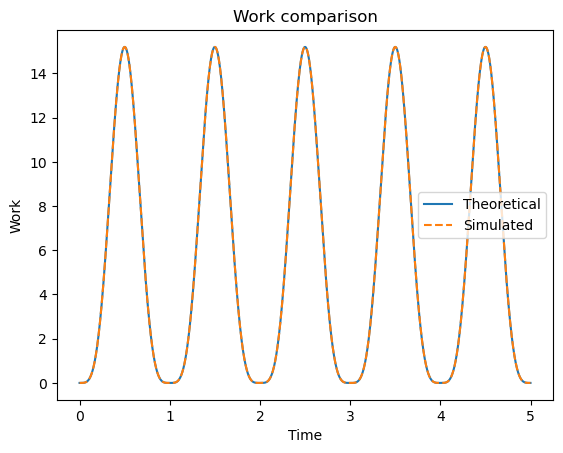

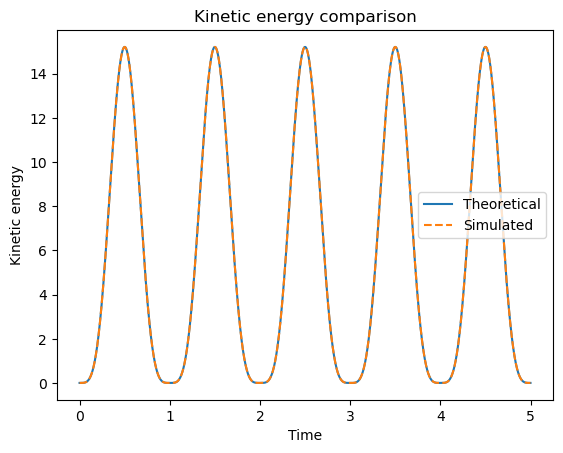

In [18]:
W = N_objects * external_force_constant**2 * masses[0] / (4*np.pi**2) * ( 0.25*np.cos(4 * np.pi * times) - np.cos(2 * np.pi * times) + 0.75 )

v0_squared = 1  # and 0 for one object
T = 0.5 * masses[0] * ( (N_objects-1) * v0_squared + N_objects * external_force_constant**2 / (4*np.pi**2) * (1 - np.cos(2 * np.pi * times))**2 )

plt.plot(times, W, label='Theoretical')
plt.plot(times, total_work, label='Simulated', linestyle='dashed')
plt.xlabel('Time')
plt.ylabel('Work')
plt.title('Work comparison')
plt.legend()
plt.show()

plt.plot(times, T, label='Theoretical')
plt.plot(times, kinetic_total, label='Simulated', linestyle='dashed')
plt.xlabel('Time')
plt.ylabel('Kinetic energy')
plt.title('Kinetic energy comparison')
plt.legend()
plt.show()

These plots also check out, so we can still be assured that the simulation is working correctly.